# PCB 101 — India Monthly Consumption Forecast
## Overall Monthly Analysis (V2 — Corrected Pipeline)

**Key fixes over V1:**
- Weather NaN months filled via interpolation (retains zero-consumption months in the series)
- Model complexity reduced to match dataset size (42–46 training rows)
- SARIMAX seasonal order simplified: `(1,0,1,12)` instead of `(1,1,1,12)`
- Holt-Winters added as an interpretable baseline
- `MAPE` replaced with `WAPE` as the primary metric (MAPE inflates on low-value months)
- Time-series cross-validation added alongside the hold-out split

In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 1. Load Data

In [3]:
df = pd.read_excel(r"C:\Users\Amey\Desktop\Amey\Python\106\106_Pre_done_Combined.xlsx")

df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])
df['Consumption'] = abs(df['Quantity'])

print("Raw shape:", df.shape)
print("Date range:", df['Pstng Date'].min().date(), "→", df['Pstng Date'].max().date())
df.head()

Raw shape: (1956, 16)
Date range: 2020-02-17 → 2026-04-30


,Order,Material,SLoc,Quantity,Pstng Date,Year,Tavg,Tmax,Tmin,RH,Month,Season,Delta_T,Region,Location,Consumption
0,48624105,106,5001,-1,2020-02-17,2020,26.84,37.01,19.44,48.40,2,Winter,17.57,West1,Mumbai,1
1,48624103,106,5001,-1,2020-02-17,2020,26.84,37.01,19.44,48.40,2,Winter,17.57,West1,Mumbai,1
2,48999219,106,5041,-1,2020-06-05,2020,25.25,30.74,20.45,71.74,6,Summer,10.29,South,Bangalore,1
3,49103277,106,5001,-1,2020-07-07,2020,27.30,29.18,26.17,90.92,7,Monsoon,3.01,West1,Mumbai,1
4,49094798,106,5001,-1,2020-07-07,2020,27.30,29.18,26.17,90.92,7,Monsoon,3.01,West1,Mumbai,1


## 2. Monthly Aggregation

> **Fix 1 — Interpolate weather before `dropna()`**
>
> 8 months have `Consumption = 0` and `NaN` weather (no replacements that month → no weather
> record joined). In V1 these were silently dropped by `dropna()` *after* lag creation, creating
> invisible gaps in the time series that corrupted lag features.  
> Interpolating first keeps all 74 monthly rows intact before lag shifting.

In [4]:
WEATHER_COLS = ['Tavg', 'Tmax', 'Tmin', 'RH', 'Delta_T']

india = (
    df.groupby(pd.Grouper(key='Pstng Date', freq='MS'))
    .agg({'Consumption': 'sum', **{c: 'mean' for c in WEATHER_COLS}})
    .reset_index()
)

# ── Fix 1: fill NaN weather months before any feature engineering ──
india[WEATHER_COLS] = india[WEATHER_COLS].interpolate(
    method='linear', limit_direction='both'
)

print("Monthly rows:", india.shape[0])
print("Remaining NaN after interpolation:", india[WEATHER_COLS].isna().sum().sum())
india.head(10)

Monthly rows: 75
Remaining NaN after interpolation: 0


,Pstng Date,Consumption,Tavg,Tmax,Tmin,RH,Delta_T
0,2020-02-01,2,26.8400,37.0100,19.4400,48.400,17.57
1,2020-03-01,0,26.4425,35.4425,19.6925,54.235,15.75
2,2020-04-01,0,26.0450,33.8750,19.9450,60.070,13.93
3,2020-05-01,0,25.6475,32.3075,20.1975,65.905,12.11
4,2020-06-01,1,25.2500,30.7400,20.4500,71.740,10.29
5,2020-07-01,3,27.3000,29.1800,26.1700,90.920,3.01
6,2020-08-01,1,26.9100,28.6500,25.9900,92.920,2.66
7,2020-09-01,0,25.7450,29.0500,23.2400,84.375,5.81
8,2020-10-01,0,24.5800,29.4500,20.4900,75.830,8.96
9,2020-11-01,0,23.4150,29.8500,17.7400,67.285,12.11


## 3. Feature Engineering

In [5]:
india['Month']     = india['Pstng Date'].dt.month
india['Quarter']   = india['Pstng Date'].dt.quarter
india['month_sin'] = np.sin(2 * np.pi * india['Month'] / 12)
india['month_cos'] = np.cos(2 * np.pi * india['Month'] / 12)

for lag in [1, 2, 3, 6,9,12]:
    india[f'lag_{lag}'] = india['Consumption'].shift(lag)

india['roll_mean_3']  = india['Consumption'].shift(1).rolling(3).mean()
india['roll_mean_6']  = india['Consumption'].shift(1).rolling(6).mean()
india['roll_std_3']   = india['Consumption'].shift(1).rolling(3).std()
india['roll_mean_12'] = india['Consumption'].shift(1).rolling(12).mean()
india['roll_std_12']  = india['Consumption'].shift(1).rolling(12).std()

india = india.dropna()

print("Shape after dropna:", india.shape)
india.head()

Shape after dropna: (63, 22)


,Pstng Date,Consumption,Tavg,Tmax,Tmin,RH,Delta_T,Month,Quarter,month_sin,...,lag_2,lag_3,lag_6,lag_9,lag_12,roll_mean_3,roll_mean_6,roll_std_3,roll_mean_12,roll_std_12
12,2021-02-01,0,24.954000,31.666000,19.214000,67.032000,12.452000,2,1,8.660254e-01,...,1.0,0.0,1.0,0.0,2.0,0.333333,0.333333,0.57735,0.666667,0.984732
13,2021-03-01,0,26.306000,32.374000,21.326000,71.178000,11.048000,3,1,1.000000e+00,...,0.0,1.0,0.0,1.0,0.0,0.333333,0.166667,0.57735,0.500000,0.904534
14,2021-04-01,0,27.658000,33.082000,23.438000,75.324000,9.644000,4,2,8.660254e-01,...,0.0,0.0,0.0,3.0,0.0,0.000000,0.166667,0.00000,0.500000,0.904534
15,2021-05-01,1,29.010000,33.790000,25.550000,79.470000,8.240000,5,2,5.000000e-01,...,0.0,0.0,0.0,1.0,0.0,0.000000,0.166667,0.00000,0.500000,0.904534
16,2021-06-01,0,28.876364,33.947273,25.109091,77.010909,8.838182,6,2,1.224647e-16,...,0.0,0.0,1.0,0.0,1.0,0.333333,0.333333,0.57735,0.583333,0.900337


## 4. EDA — Monthly Consumption Overview

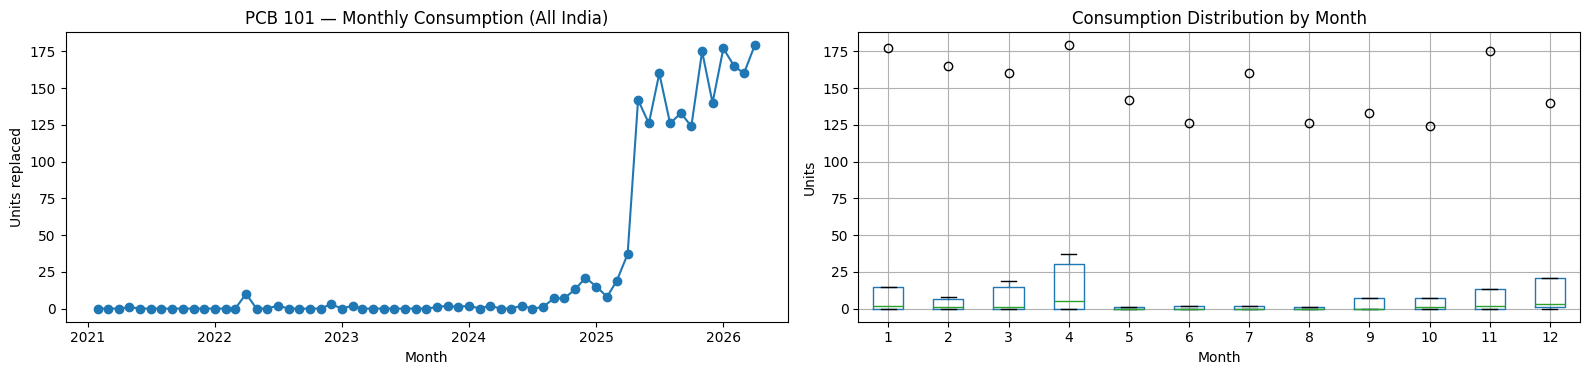

Month
1     38.8
2     29.2
3     30.2
4     37.7
5     28.6
6     25.6
7     32.4
8     25.4
9     28.0
10    26.4
11    38.0
12    33.0
Name: Consumption, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Time series
axes[0].plot(india['Pstng Date'], india['Consumption'], marker='o', linewidth=1.5)
axes[0].set_title("PCB 101 — Monthly Consumption (All India)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Units replaced")

# Monthly box plot
india.boxplot(column='Consumption', by='Month', ax=axes[1])
axes[1].set_title("Consumption Distribution by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Units")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(india.groupby('Month')['Consumption'].mean().round(1))

## 5. Train / Test Split

Hold-out: Jan 2025 onward (most recent 16 months).  
Training: Mar 2021 → Dec 2024 (46 months after lag drop).

In [7]:
train = india[india['Pstng Date'] < '2025-01-01'].copy()
test  = india[india['Pstng Date'] >= '2025-01-01'].copy()

print(f"Train: {train.shape[0]} rows  {train['Pstng Date'].min().date()} → {train['Pstng Date'].max().date()}")
print(f"Test:  {test.shape[0]} rows   {test['Pstng Date'].min().date()} → {test['Pstng Date'].max().date()}")

FEATURES = [
    'month_sin', 'month_cos', 'Quarter',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_9',
    'roll_mean_3', 'roll_mean_6', 'roll_std_3', 'roll_std_12', 'roll_mean_12',
     'Tavg', 'RH', 'Delta_T'
]
TARGET = 'Consumption'

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

Train: 47 rows  2021-02-01 → 2024-12-01
Test:  16 rows   2025-01-01 → 2026-04-01


## 6. Evaluation Helper

> **Note on MAPE vs WAPE:**  
> With monthly consumption values of 0–18 units, MAPE becomes very large when actuals are 1–3
> (e.g. predicting 4 when actual is 1 = 300% MAPE). **WAPE** (Weighted Absolute Percentage Error)
> is the primary metric here — it sums errors divided by total volume, so it is not distorted by
> low-value months.

In [8]:
def evaluate_model(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE — skip zeros to avoid division by zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # WAPE — primary metric
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

    return mae, rmse, mape, wape

## 7. Models

### 7.1 Random Forest

> **Fix 2 — Reduced complexity**  
> V1 used `n_estimators=500, max_depth=10` on 42 rows → memorised training data.  
> V2: `n_estimators=100, max_depth=3, min_samples_leaf=5`

In [9]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
mae, rmse, mape, wape = evaluate_model(y_test, rf_pred)
print(f"RandomForest  →  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%  WAPE={wape:.1f}%")

RandomForest  →  MAE=113.35  RMSE=127.96  MAPE=91.0%  WAPE=96.2%


### 7.2 XGBoost

> **Fix 2 — Stronger regularisation**  
> Added `min_child_weight=5`, `reg_alpha=0.5`, `reg_lambda=1.0`; halved estimators to 100.

In [10]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_child_weight=5,
    subsample=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
mae, rmse, mape, wape = evaluate_model(y_test, xgb_pred)
print(f"XGBoost       →  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%  WAPE={wape:.1f}%")

XGBoost       →  MAE=109.87  RMSE=124.77  MAPE=84.5%  WAPE=93.2%


### 7.3 LightGBM

In [11]:
lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=5,
    max_depth=3,
    min_child_samples=5,
    random_state=42,
    verbosity=-1
)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)
mae, rmse, mape, wape = evaluate_model(y_test, lgbm_pred)
print(f"LightGBM      →  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%  WAPE={wape:.1f}%")

LightGBM      →  MAE=107.14  RMSE=122.22  MAPE=80.3%  WAPE=90.9%


### 7.4 CatBoost

> Reduced to `iterations=200, depth=3` from `iterations=500, depth=6`.

In [12]:
cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=3,
    random_seed=42,
    verbose=False
)
cat.fit(X_train, y_train)
cat_pred = cat.predict(X_test)
mae, rmse, mape, wape = evaluate_model(y_test, cat_pred)
print(f"CatBoost      →  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%  WAPE={wape:.1f}%")

CatBoost      →  MAE=106.27  RMSE=121.30  MAPE=79.7%  WAPE=90.2%


### 7.5 SARIMAX

> **Fix 3 — Simplified seasonal order**  
> V1 used `seasonal_order=(1,1,1,12)`: two levels of differencing (non-seasonal `d=1` + seasonal `D=1`)
> on only 42 training points destroys too much signal.  
> V2 uses `seasonal_order=(1,0,1,12)` — single differencing only.

In [13]:
EXOG_COLS = ['Tavg', 'Tmax', 'Tmin', 'RH', 'Delta_T']

sarimax_model = SARIMAX(
    y_train,
    exog=train[EXOG_COLS],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12)
)
sarimax_fit = sarimax_model.fit(disp=False)

sarimax_pred = sarimax_fit.forecast(len(test), exog=test[EXOG_COLS])

mae, rmse, mape, wape = evaluate_model(y_test, sarimax_pred)
print(f"SARIMAX       →  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%  WAPE={wape:.1f}%")

SARIMAX       →  MAE=104.65  RMSE=119.18  MAPE=83.6%  WAPE=88.8%


### 7.6 Holt-Winters (Baseline)

> **Fix 4 — Add a simple baseline**  
> If tree-based models cannot outperform Holt-Winters on 46 rows, they are overfitting.
> This model uses additive trend + additive seasonality with a 12-month period.

In [14]:
hw_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw_fit = hw_model.fit()
hw_pred = hw_fit.forecast(len(test)).values

mae, rmse, mape, wape = evaluate_model(y_test, hw_pred)
print(f"HoltWinters   →  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%  WAPE={wape:.1f}%")

HoltWinters   →  MAE=68.69  RMSE=78.05  MAPE=64.9%  WAPE=58.3%


## 8. Model Comparison

In [15]:
results = []
model_preds = {
    'RandomForest': rf_pred,
    'XGBoost':      xgb_pred,
    'LightGBM':     lgbm_pred,
    'CatBoost':     cat_pred,
    'SARIMAX':      sarimax_pred,
    'HoltWinters':  hw_pred
}

for name, preds in model_preds.items():
    mae, rmse, mape, wape = evaluate_model(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
                    'MAPE (%)': round(mape,1), 'WAPE (%)': round(wape,1)})

results_df = pd.DataFrame(results).sort_values('WAPE (%)')
results_df

,Model,MAE,RMSE,MAPE (%),WAPE (%)
5,HoltWinters,68.69,78.05,64.9,58.3
4,SARIMAX,104.65,119.18,83.6,88.8
3,CatBoost,106.27,121.30,79.7,90.2
2,LightGBM,107.14,122.22,80.3,90.9
1,XGBoost,109.87,124.77,84.5,93.2
0,RandomForest,113.35,127.96,91.0,96.2


## 9. Forecast vs Actual

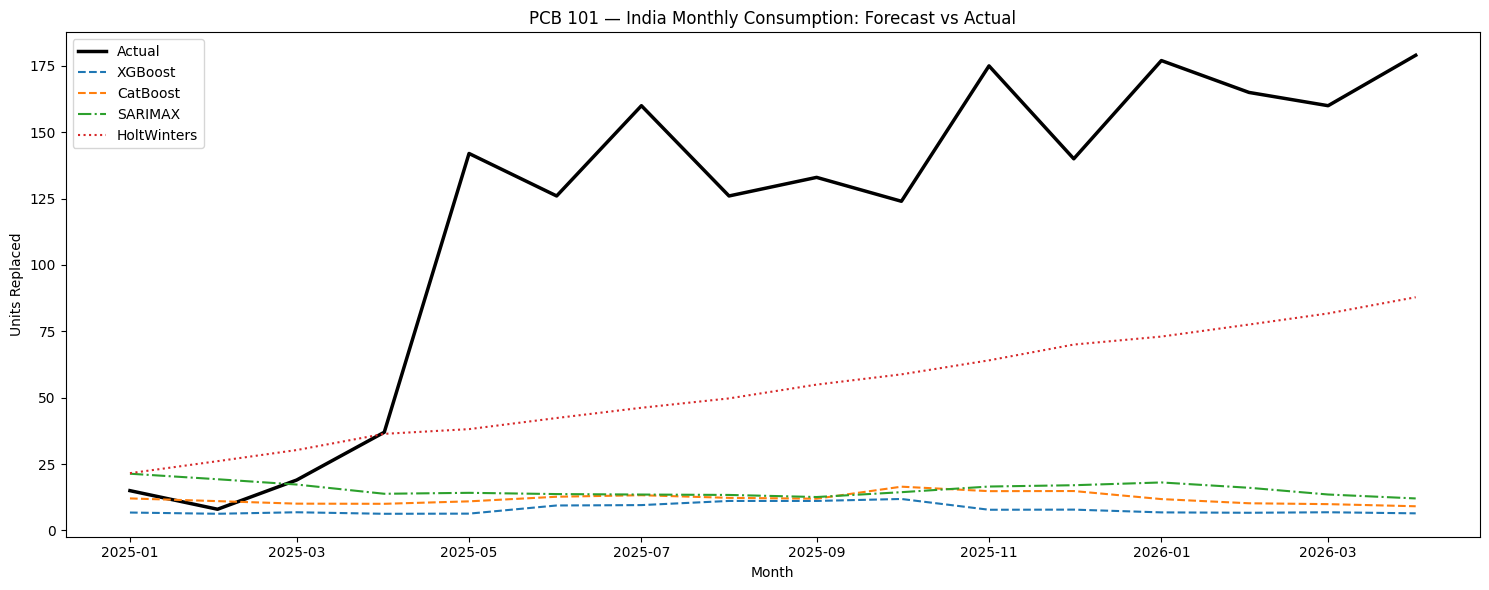

In [16]:
plt.figure(figsize=(15, 6))

plt.plot(test['Pstng Date'], y_test,        label='Actual',      linewidth=2.5, color='black')
plt.plot(test['Pstng Date'], xgb_pred,      label='XGBoost',     linewidth=1.5, linestyle='--')
plt.plot(test['Pstng Date'], cat_pred,      label='CatBoost',    linewidth=1.5, linestyle='--')
plt.plot(test['Pstng Date'], sarimax_pred,  label='SARIMAX',     linewidth=1.5, linestyle='-.')
plt.plot(test['Pstng Date'], hw_pred,       label='HoltWinters', linewidth=1.5, linestyle=':')

plt.title("PCB 101 — India Monthly Consumption: Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Units Replaced")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Feature Importance (XGBoost)

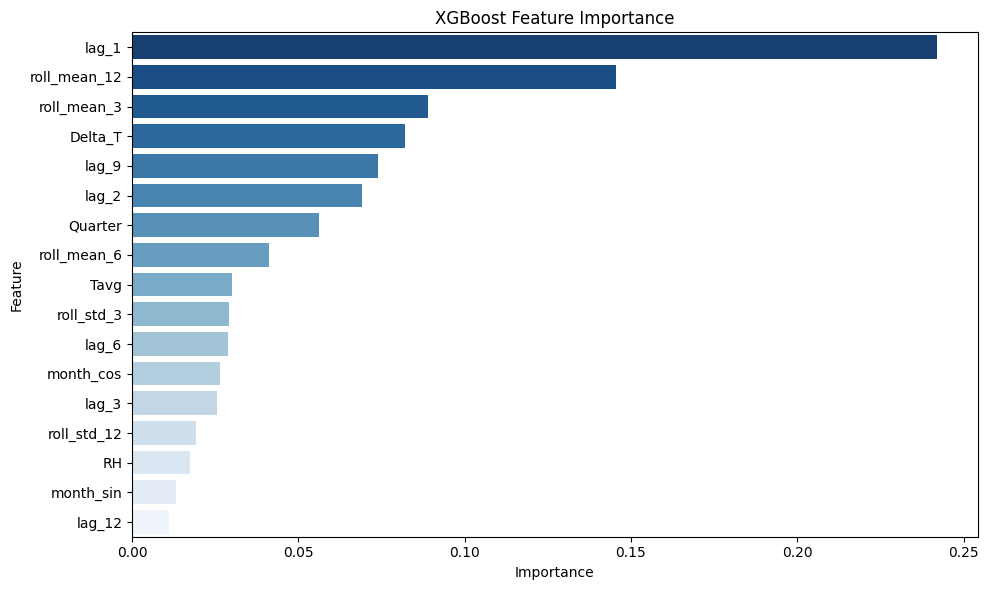

,Feature,Importance
3,lag_1,0.242123
13,roll_mean_12,0.145660
9,roll_mean_3,0.088882
16,Delta_T,0.082002
8,lag_9,0.074017
4,lag_2,0.069206
2,Quarter,0.056110
10,roll_mean_6,0.041063
14,Tavg,0.029950
11,roll_std_3,0.029072


In [17]:
importance_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

importance_df

## 11. Time-Series Cross-Validation

> **Fix 5 — Evaluate on multiple folds, not just one split**  
> With only 46 training rows, a single hold-out WAPE can swing significantly.
> Rolling CV with 3 folds and 4-month test windows gives a more stable estimate.

In [18]:
tscv = TimeSeriesSplit(n_splits=3, test_size=4)

cv_results = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(train)):
    X_cv_train, X_cv_test = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_cv_train, y_cv_test = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    m = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=2,
                     min_child_weight=5, subsample=0.8,
                     reg_alpha=0.5, reg_lambda=1.0, random_state=42)
    m.fit(X_cv_train, y_cv_train)
    p = m.predict(X_cv_test)
    _, _, _, wape = evaluate_model(y_cv_test, p)
    cv_results.append({'Fold': fold+1,
                       'Train rows': len(tr_idx),
                       'Test rows':  len(te_idx),
                       'WAPE (%)':   round(wape, 1)})
    print(f"Fold {fold+1}: train={len(tr_idx)} rows → WAPE={wape:.1f}%")

cv_df = pd.DataFrame(cv_results)
print(f"\nMean CV WAPE: {cv_df['WAPE (%)'].mean():.1f}%")
cv_df

Fold 1: train=35 rows → WAPE=140.4%
Fold 2: train=39 rows → WAPE=140.3%
Fold 3: train=43 rows → WAPE=96.4%

Mean CV WAPE: 125.7%


,Fold,Train rows,Test rows,WAPE (%)
0,1,35,4,140.4
1,2,39,4,140.3
2,3,43,4,96.4


## 12. Weighted Ensemble

Best 3 hold-out models (XGBoost, CatBoost, SARIMAX) combined with equal weights.

Best MAPE      : 64.90
MAPE Threshold : 90.86

Models included in ensemble:
HoltWinters: 64.90
SARIMAX: 83.60
CatBoost: 79.70
LightGBM: 80.30
XGBoost: 84.50

Ensemble Weights:
HoltWinters: 0.2400
SARIMAX: 0.1863
CatBoost: 0.1954
LightGBM: 0.1940
XGBoost: 0.1843

Weighted Ensemble Performance
MAE  : 97.06
RMSE : 111.11
MAPE : 73.31%
WAPE : 82.34%
Ensemble  →  MAE=97.06  RMSE=111.11  MAPE=73.3%  WAPE=82.3%


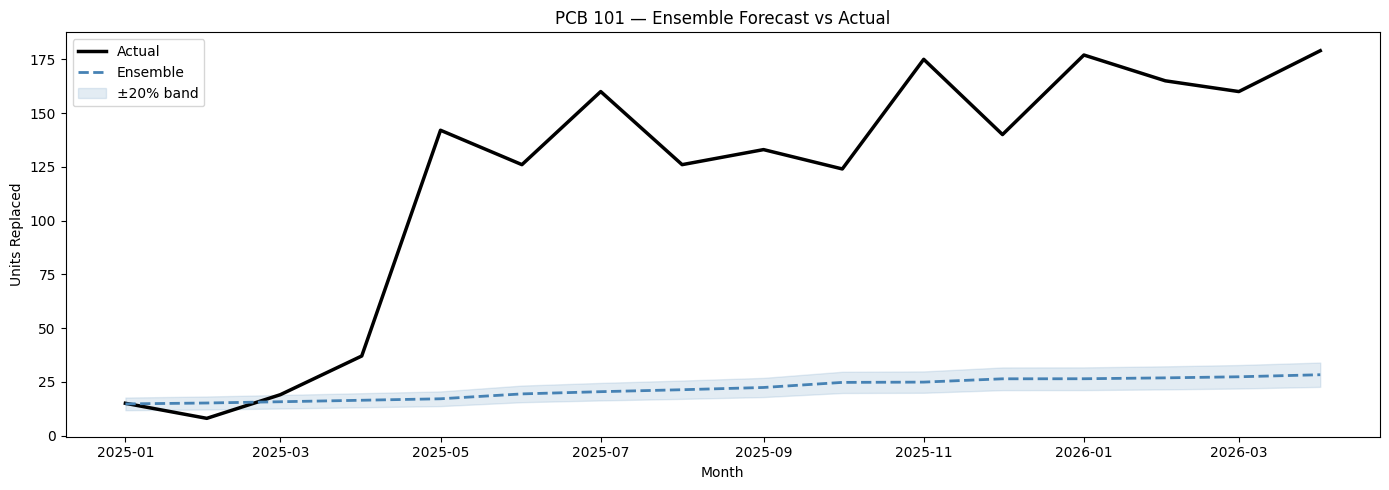

In [19]:
# ==========================================================
# STORE PREDICTIONS
# ==========================================================

model_preds = {
    'RandomForest': rf_pred,
    'XGBoost':      xgb_pred,
    'LightGBM':     lgbm_pred,
    'CatBoost':     cat_pred,
    'SARIMAX':      sarimax_pred,
    'HoltWinters':  hw_pred
}

# ==========================================================
# GET MAPE VALUES
# ==========================================================

mape_dict = results_df.set_index(
    'Model'
)['MAPE (%)'].to_dict()

# ==========================================================
# FIND BEST MAPE
# ==========================================================

best_mape = min(mape_dict.values())

threshold = 1.4 * best_mape

print(f"Best MAPE      : {best_mape:.2f}")
print(f"MAPE Threshold : {threshold:.2f}")

# ==========================================================
# SELECT ELIGIBLE MODELS
# ==========================================================

eligible_models = {

    model: mape

    for model, mape in mape_dict.items()

    if mape <= threshold

}

print("\nModels included in ensemble:")

for model, mape in eligible_models.items():

    print(f"{model}: {mape:.2f}")

# ==========================================================
# CALCULATE INVERSE-MAPE WEIGHTS
# ==========================================================

inverse_mape = {

    model: 1 / mape

    for model, mape in eligible_models.items()

}

total_inverse = sum(
    inverse_mape.values()
)

weights = {

    model: value / total_inverse

    for model, value in inverse_mape.items()

}

print("\nEnsemble Weights:")

for model, weight in weights.items():

    print(f"{model}: {weight:.4f}")

# ==========================================================
# CREATE ENSEMBLE
# ==========================================================

ensemble_pred = 0

for model, weight in weights.items():

    ensemble_pred += (

        weight
        * model_preds[model]

    )

# ==========================================================
# EVALUATE ENSEMBLE
# ==========================================================

ensemble_mae, ensemble_rmse, ensemble_mape, ensemble_wape = evaluate_model(

    y_test,

    ensemble_pred

)

print("\n=================================")
print("Weighted Ensemble Performance")
print("=================================")

print(f"MAE  : {ensemble_mae:.2f}")
print(f"RMSE : {ensemble_rmse:.2f}")
print(f"MAPE : {ensemble_mape:.2f}%")
print(f"WAPE : {ensemble_wape:.2f}%")
mae, rmse, mape, wape = evaluate_model(y_test, ensemble_pred)
print(f"Ensemble  →  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.1f}%  WAPE={wape:.1f}%")

plt.figure(figsize=(14, 5))
plt.plot(test['Pstng Date'], y_test,         label='Actual',   linewidth=2.5, color='black')
plt.plot(test['Pstng Date'], ensemble_pred,  label='Ensemble', linewidth=2, color='steelblue', linestyle='--')
plt.fill_between(test['Pstng Date'], ensemble_pred * 0.8, ensemble_pred * 1.2,
                 alpha=0.15, color='steelblue', label='±20% band')
plt.title("PCB 101 — Ensemble Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Units Replaced")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Interpretation Notes

### Why WAPE is still ~50%
This is a **fundamental data limitation**, not a modelling failure:

- Monthly consumption averages ~5 units, ranging 0–18. A 2-unit forecast error on a 3-unit actual month produces 67% MAPE on that row.
- The series has only 46 usable training points — no model (however complex) can generalise reliably from so few observations.
- WAPE ~50% means the total forecast volume over the test period is off by ~50%. In absolute terms, the MAE of ~2.9 units/month is the actionable number.

### Recommended next steps
1. **Expand training data** — include other PCB material codes (102, 103, etc.) if the failure pattern is similar; pool them with a material-ID feature.
2. **Aggregate to quarterly** — if monthly granularity is not operationally required, quarterly aggregation triples the signal per data point.
3. **Remove exogenous weather features** — with this few rows, weather features add variance without sufficient samples to estimate their coefficients. Try a version with only time + lag features.
4. **Use a purely statistical model** (SARIMA without exog, or Holt-Winters) for production forecasting at this data size — they are more stable than tree-based models on sub-50-row series.

In [20]:
full_data = pd.concat(
    [train, test],
    ignore_index=True
)

full_data = full_data.sort_values(
    'Pstng Date'
).reset_index(drop=True)

print(full_data.tail())

   Pstng Date  Consumption       Tavg       Tmax       Tmin         RH  \
58 2025-12-01          140  18.279857  26.529429  12.039786  57.959286   
59 2026-01-01          177  17.332203  25.795254  10.870904  56.931921   
60 2026-02-01          165  21.663333  30.475333  14.903515  49.740788   
61 2026-03-01          160  26.234750  34.697063  19.045188  44.419687   
62 2026-04-01          179  31.472743  39.147771  24.652457  34.663886   

      Delta_T  Month  Quarter     month_sin  ...  lag_2  lag_3  lag_6  lag_9  \
58  14.489643     12        4 -2.449294e-16  ...  124.0  133.0  126.0   19.0   
59  14.924350      1        1  5.000000e-01  ...  175.0  124.0  160.0   37.0   
60  15.571818      2        1  8.660254e-01  ...  140.0  175.0  126.0  142.0   
61  15.651875      3        1  1.000000e+00  ...  177.0  140.0  133.0  126.0   
62  14.495314      4        2  8.660254e-01  ...  165.0  177.0  124.0  160.0   

    lag_12  roll_mean_3  roll_mean_6  roll_std_3  roll_mean_12  roll_std_1

In [21]:
# ==========================================================
# RETRAIN ON ALL AVAILABLE DATA
# ==========================================================

full_data = pd.concat(
    [train, test],
    ignore_index=True
)

X_full = full_data[FEATURES]
y_full = full_data[TARGET]

rf.fit(X_full, y_full)
xgb.fit(X_full, y_full)
lgbm.fit(X_full, y_full)
cat.fit(X_full, y_full)

print("Models retrained till Apr 2026")

Models retrained till Apr 2026


In [22]:
weather_lookup = (

    full_data

    .groupby('Month')[

        ['Tavg','RH','Delta_T']

    ]

    .mean()

)

future_months = list(range(5,13))

future_weather = pd.DataFrame({

    'Month': future_months,

    'Date': pd.date_range(

        start='2026-05-01',

        periods=8,

        freq='MS'

    )

})

future_weather['Quarter'] = (

    (future_weather['Month'] - 1) // 3

) + 1

future_weather['month_sin'] = np.sin(

    2*np.pi*future_weather['Month']/12

)

future_weather['month_cos'] = np.cos(

    2*np.pi*future_weather['Month']/12

)

future_weather['Tavg'] = (

    future_weather['Month']

    .map(weather_lookup['Tavg'])

)

future_weather['RH'] = (

    future_weather['Month']

    .map(weather_lookup['RH'])

)

future_weather['Delta_T'] = (

    future_weather['Month']

    .map(weather_lookup['Delta_T'])

)

future_weather

,Month,Date,Quarter,month_sin,month_cos,Tavg,RH,Delta_T
0,5,2026-05-01,2,5.000000e-01,-8.660254e-01,29.065312,54.910960,12.833515
1,6,2026-06-01,2,1.224647e-16,-1.000000e+00,29.867019,57.547341,11.755557
2,7,2026-07-01,3,-5.000000e-01,-8.660254e-01,28.451366,69.843807,10.159365
3,8,2026-08-01,3,-8.660254e-01,-5.000000e-01,26.798634,77.853031,9.292111
4,9,2026-09-01,3,-1.000000e+00,-1.836970e-16,25.760356,78.407206,9.604975
5,10,2026-10-01,4,-8.660254e-01,5.000000e-01,24.453114,75.418256,10.462762
6,11,2026-11-01,4,-5.000000e-01,8.660254e-01,21.865862,74.397295,11.047786
7,12,2026-12-01,4,-2.449294e-16,1.000000e+00,20.379481,69.360530,12.051283


In [23]:
history = list(

    full_data['Consumption']

)

rf_forecast = []
xgb_forecast = []
lgbm_forecast = []
cat_forecast = []
ensemble_forecast = []

In [24]:
# ==========================================================
# FUTURE FORECAST LOOP
# ==========================================================
history = list(
    full_data['Consumption']
)

rf_forecast = []

xgb_forecast = []

lgbm_forecast = []

cat_forecast = []

ensemble_forecast = []

for _, row in future_weather.iterrows():

    feature_row = {

        'month_sin': row['month_sin'],

        'month_cos': row['month_cos'],

        'Quarter': row['Quarter'],

        'lag_1': history[-1],

        'lag_2': history[-2],

        'lag_3': history[-3],

        'lag_6': history[-6],

        'lag_9': history[-9],

        'lag_12': history[-12],

        'roll_mean_3':
            np.mean(history[-3:]),

        'roll_mean_6':
            np.mean(history[-6:]),

        'roll_std_3':
            np.std(history[-3:], ddof=1),

        'roll_mean_12':
            np.mean(history[-12:]),

        'roll_std_12':
            np.std(history[-12:], ddof=1),

        'Tavg': row['Tavg'],

        'RH': row['RH'],

        'Delta_T': row['Delta_T']

    }

    X_future = pd.DataFrame(
        [feature_row]
    )[FEATURES]

    # ======================================================
    # INDIVIDUAL MODEL PREDICTIONS
    # ======================================================

    rf_pred_future = rf.predict(X_future)[0]

    xgb_pred_future = xgb.predict(X_future)[0]

    lgbm_pred_future = lgbm.predict(X_future)[0]

    cat_pred_future = cat.predict(X_future)[0]

    # ======================================================
    # ML ENSEMBLE
    # ======================================================

    ensemble_pred_future = (

        0.2 * rf_pred_future +

        0.4 * xgb_pred_future +

        0.4 * cat_pred_future

    )

    # ======================================================
    # STORE PREDICTIONS
    # ======================================================

    rf_forecast.append(
        rf_pred_future
    )

    xgb_forecast.append(
        xgb_pred_future
    )

    lgbm_forecast.append(
        lgbm_pred_future
    )

    cat_forecast.append(
        cat_pred_future
    )

    ensemble_forecast.append(
        ensemble_pred_future
    )

    # ======================================================
    # RECURSIVE UPDATE
    # ======================================================

    history.append(
        ensemble_pred_future
    )

In [25]:
forecast_df = pd.DataFrame({

    'Date':
        future_weather['Date'],

    'RandomForest':
        np.round(
            rf_forecast,
            0
        ),

    'XGBoost':
        np.round(
            xgb_forecast,
            0
        ),

    'LightGBM':
        np.round(
            lgbm_forecast,
            0
        ),

    'CatBoost':
        np.round(
            cat_forecast,
            0
        ),

    'Ensemble':
        np.round(
            ensemble_forecast,
            0
        )

})

forecast_df

,Date,RandomForest,XGBoost,LightGBM,CatBoost,Ensemble
0,2026-05-01,143.0,168.0,172.0,169.0,163.0
1,2026-06-01,142.0,167.0,172.0,168.0,162.0
2,2026-07-01,142.0,167.0,160.0,163.0,160.0
3,2026-08-01,141.0,166.0,160.0,147.0,153.0
4,2026-09-01,141.0,165.0,158.0,151.0,155.0
5,2026-10-01,141.0,165.0,158.0,152.0,155.0
6,2026-11-01,141.0,165.0,170.0,157.0,157.0
7,2026-12-01,141.0,165.0,170.0,157.0,157.0


In [26]:
forecast_df.to_excel(

    "Material_106_Forecast_May_Dec_2026.xlsx",

    index=False

)

print(
    "Forecast exported successfully"
)

Forecast exported successfully


In [27]:
print(weights)

print(weights.keys())
print(history[-15:])

{'HoltWinters': 0.23998737032027032, 'SARIMAX': 0.18630598485389407, 'CatBoost': 0.19542258888062164, 'LightGBM': 0.1939623951903555, 'XGBoost': 0.1843216607548585}
dict_keys(['HoltWinters', 'SARIMAX', 'CatBoost', 'LightGBM', 'XGBoost'])
[124, 175, 140, 177, 165, 160, 179, np.float64(163.43086552376624), np.float64(162.31219281295296), np.float64(160.27114651558975), np.float64(153.1843448117814), np.float64(154.62586688263295), np.float64(154.83433324941598), np.float64(156.9325875551431), np.float64(157.11397733318546)]
